#MNIST

In [2]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
print(mnist.data.shape)

(70000, 784)


In [1]:
import pandas as pd
print(pd.__version__)

3.0.5


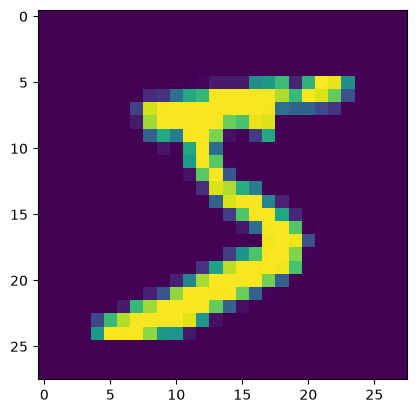

5


In [3]:
import matplotlib.pyplot as plt
plt.imshow(mnist.data[0].reshape(28,28) )
plt.show()

print(mnist.target[0])

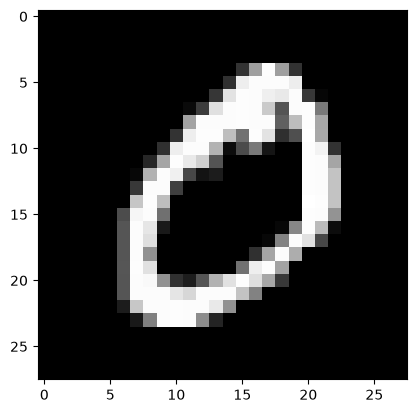

0


In [7]:
plt.imshow(mnist.data[1].reshape(28,28), cmap='grey')
plt.show()
print(mnist.target[1])

In [ ]:
X= mnist.data
y = mnist.target
X = X/255.0
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=96 #fixing the random shuffling order
)

#KNN Classifier

In [15]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

# Features and labels
X = mnist.data
y = mnist.target

# Scale
X = X / 255.0

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=96
)

# Create KNN model
model = KNeighborsClassifier(n_neighbors=3)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
X= mnist.data
y = mnist.target
X = X/255.0
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=96 #fixing the random shuffling order
)
model = KNeighborsClassifier(n_neighbors=7)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


Accuracy: 0.9721428571428572
Accuracy: 0.9705714285714285


#MINIMUM DISTANCE CLASSIFIER

In [2]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

# Load MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data
y = mnist.target

# Scale
X = X / 255.0

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=96
)

# Find center of each class
class_centers = []

for digit in range(10):
    class_data = X_train[y_train == str(digit)]
    center = np.mean(class_data, axis=0)
    class_centers.append(center)

class_centers = np.array(class_centers)

# Prediction
predictions = []

for image in X_test:
    distances = []

    for center in class_centers:
        distance = np.linalg.norm(image - center)
        distances.append(distance)

    predictions.append(np.argmin(distances))

predictions = np.array(predictions).astype(str)

# Accuracy
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Accuracy: 0.8105714285714286


#linear regression

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error ,r2_score

X = np.array([[1], [2], [3], [4], [5]])
y = np.array([20, 30, 40, 50, 60])

model = LinearRegression()

model.fit(X, y)

y_pred = model.predict(X)

print("Predictions:", y_pred)
print("Slope:", model.coef_)
print("Intercept:", model.intercept_)

mse = mean_squared_error(y, y_pred)
print("MSE:", mse)

Predictions: [20. 30. 40. 50. 60.]
Slope: [10.]
Intercept: 10.000000000000007
MSE: 1.262177448353619e-29


#non-linear regression
(didn't get the code clearly)

In [ ]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Data
X = np.array([[1], [2], [3], [4], [5]])
y = np.array([1, 4, 9, 16, 25])

# Convert X into polynomial features
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

y_pred = model.predict(X_poly)

print("Predictions:", y_pred)
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# Error
mse = mean_squared_error(y, y_pred)
print("MSE:", mse)

Predictions: [ 1.  4.  9. 16. 25.]
Coefficients: [ 0.00000000e+00 -8.77076189e-15  1.00000000e+00]
Intercept: 7.105427357601002e-15
MSE: 1.5146129380243426e-29


#logistic regression

MNIST image
   ↓
784 pixel values
   ↓
Logistic Regression
   ↓
probability for each digit
   ↓
highest probability
   ↓
0–9

In [9]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data
y = mnist.target

X = X / 255.0

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=96
)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9225


c:\Users\SONAKSHI GOYAL\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#SVM
The important idea is the margin: SVM tries to keep the boundary as far as possible from the closest training points.

In [ ]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data
y = mnist.target

X = X / 255.0

X = X[:2000]
y = y[:2000]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=96
)

# Create SVM model
model = SVC(kernel='rbf') didnt get the rbf clearly

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9475


#random forest
 MNIST image
                  ↓
       ┌──────┬──────┬──────┐
       ↓      ↓      ↓      ↓
     Tree1  Tree2  Tree3  ... TreeN
       ↓      ↓      ↓
       5      5      3
              ↓
        majority voting
              ↓
              5

In [11]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data
y = mnist.target

X = X / 255.0

X = X[:2000]
y = y[:2000]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=58
)

model = RandomForestClassifier(
    n_estimators=100, #no. of tress
    random_state= 40  #fixing the tree order
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9175


#PCA
MNIST image
   ↓
784 features
   ↓
PCA
   ↓
50 features

In [ ]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data
y = mnist.target

X = X / 255.0

X = X[:2000]
y = y[:2000]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=58
)
print('before PCA:' , X.shape)
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X)
print('after PCA:' , X_pca.shape)
model = RandomForestClassifier(
    n_estimators=100, 
    random_state= 40  
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


before PCA: (2000, 784)
after PCA: (2000, 10)
Accuracy: 0.9175


#K-Mean
If we choose:

K = 10

the algorithm tries to create 10 groups.

How it works
Choose random cluster centers.K
Assign every image to its nearest center.
Recalculate each center using the mean of the points in that cluster.
Repeat steps 2–3 until the centers stop changing much.

The important word is mean—that's why it's called K-Means.

In [ ]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data
y = mnist.target

X = X[:5000]
y = y[:5000]

X = X / 255.0

pca = PCA(n_components=10)
X_pca = pca.fit_transform(X)

model = KMeans(n_clusters=10, random_state=96, n_init=10) 
#n_init=10 means K-Means will try 10 different initial center arrangements
clusters = model.fit_predict(X)
print("Cluster labels:", clusters[:20])
# Compare clusters with actual digits
score = adjusted_rand_score(y, clusters)
print("Adjusted Rand Index:", score)

Cluster labels: [5 2 7 3 1 9 4 5 4 6 5 4 8 0 4 6 9 5 0 6]
Adjusted Rand Index: 0.3267883272201537


#k-medieod
rather than taking the mean of all points it takes the actual point from the data which is less affected by outliers

In [21]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data
y = mnist.target

X = X[:2000]
y = y[:2000]

X = X / 255.0

pca = PCA(n_components=75)
X_pca = pca.fit_transform(X)
model = KMedoids(n_clusters=10, random_state=96)
clusters = model.fit_predict(X)
score = adjusted_rand_score(y, clusters)
print("ARI:", score)

ModuleNotFoundError: No module named 'sklearn_extra'

#heirarchial clustering
Agglomerative → start with every point as its own cluster and keep merging.
Divisive → start with one big cluster and keep splitting.

In [23]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data
y = mnist.target

X = X[:2000]
y = y[:2000]

X = X / 255.0

pca = PCA(n_components=20)
X_pca = pca.fit_transform(X)

model = AgglomerativeClustering(n_clusters=10)

clusters = model.fit_predict(X_pca)

score = adjusted_rand_score(y, clusters)

print("ARI:", score)

ARI: 0.3756486349538613


#DBSCAN
The dense groups become clusters, while isolated points can be treated as noise/outliers.

In [29]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score

mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data
y = mnist.target

X = X[:2000]
y = y[:2000]

X = X / 255.0

pca = PCA(n_components=100)
X = pca.fit_transform(X)

model = DBSCAN(eps=5, min_samples=4)

clusters = model.fit_predict(X)

print("Number of clusters:", len(set(clusters)) - (1 if -1 in clusters else 0))

print("Noise points:", np.sum(clusters == -1))
score = adjusted_rand_score(y, clusters)

print("ARI:", score)

Number of clusters: 24
Noise points: 835
ARI: 0.10938630326988423


#LBP
Image
  ↓
Look at local neighborhoods
  ↓
Compare neighbors with center
  ↓
Binary patterns
  ↓
LBP features

LBP Shape: (28, 28)
8.0
[[8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8.
  8. 8. 8. 8.]
 [8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8.
  8. 8. 8. 8.]
 [8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8.
  8. 8. 8. 8.]
 [8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8.
  8. 8. 8. 8.]
 [8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8.
  8. 8. 8. 8.]
 [8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8. 5. 4. 5. 6. 4. 4. 2. 7. 3. 0. 1. 2.
  8. 8. 8. 8.]
 [8. 8. 8. 8. 8. 8. 8. 8. 4. 4. 4. 4. 4. 3. 5. 5. 9. 1. 1. 9. 0. 9. 3. 4.
  8. 8. 8. 8.]
 [8. 8. 8. 8. 8. 8. 8. 3. 2. 3. 5. 5. 5. 9. 5. 5. 3. 3. 5. 5. 4. 4. 4. 8.
  8. 8. 8. 8.]
 [8. 8. 8. 8. 8. 8. 8. 4. 3. 3. 5. 7. 7. 3. 4. 5. 2. 3. 8. 8. 8. 8. 8. 8.
  8. 8. 8. 8.]
 [8. 8. 8. 8. 8. 8. 8. 8. 3. 3. 6. 3. 9. 4. 5. 8. 4. 2. 8. 8. 8. 8. 8. 8.
  8. 8. 8. 8.]
 [8. 8. 8. 8. 8. 8. 8. 8. 8. 3. 7. 4. 9. 5. 8. 8. 8. 8. 8. 8. 8. 8. 8. 8.
  8. 8. 8. 8

c:\Users\SONAKSHI GOYAL\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\skimage\feature\texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


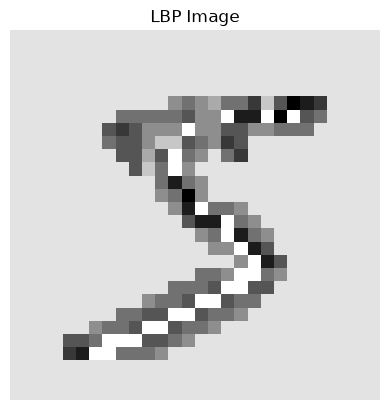

In [37]:
import numpy as np
from sklearn.datasets import fetch_openml
from skimage.feature import local_binary_pattern

mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data
y = mnist.target

X = X[:2000]
y = y[:2000]

X = X / 255.0
image = X[0].reshape(28, 28)
lbp = local_binary_pattern(image, P=8, R=1, method='uniform')

print("LBP Shape:" , lbp.shape)
print(lbp[5,5])
print(lbp)

import matplotlib.pyplot as plt

plt.imshow(lbp, cmap='gray')
plt.title("LBP Image")
plt.axis("off")
plt.show()

#HOG
Image
 ↓
Calculate gradients
 ↓
Find edge direction + strength
 ↓
Divide image into small cells
 ↓
Create orientation histograms
 ↓
Combine them into a feature vector

HOG feature shape: (324,)


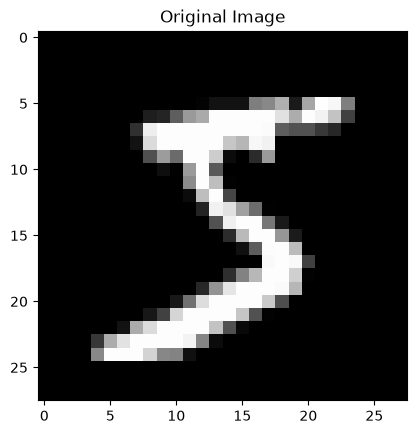

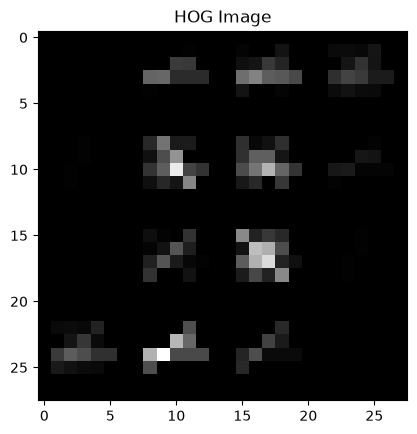

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from skimage.feature import hog

mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist.data
y = mnist.target

image = X[0].reshape(28, 28)
features, hog_image = hog(
    image,
    orientations=9,
    pixels_per_cell=(7, 7),
    cells_per_block=(2, 2),
    visualize=True
)

print("HOG feature shape:", features.shape)

plt.figure()
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.show()

plt.figure()
plt.imshow(hog_image, cmap='gray')
plt.title("HOG Image")
plt.show()